# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



# Business understanding

The data is related with direct tele-marketing campaigns of a Portuguese banking institution. The goal is to predict if the client will subscribe a term deposit.

### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### ANS:  
## The paper indicates 17 campaigns happened between May 2008 and November 2010, corresponding to a total of 79354 contacts.

# EDA (Exploratory Data Analysis)

1. CLASS IMBALANCE ANALYSIS
2. COMPARE FULL VS SUBSET DATESET TO DECIDE WHICH ONE TO CHOOSE FOR PERFORMACE ANALYSIS
3. RENAME FEATURES & TARGET VARIABLES TO APPROPAITE NAMES FOR BETTER READABILITY & UNDERSTANDING (EG. 'emp.var.rate' to 'employment_variation_rate')
4. Separate categorical & numeric features & identify unique values to chose type of encoder to be used
5. PLOT HEAT MAP TO SEE THE FEATURE CORRELATION & THEIR IMPORTANCE
6. Used OrdinalEncoder to produce HEATMAP and analysis. Chosen OrdinalEncoder over OneHotEncoding to keep dimention under control and make plot more readable
7. Use LabelEncoder for target transformation
8. Used OneHotEncoder in subsequent stages for modelling

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df_full = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df = pd.read_csv('data/bank-additional.csv', sep = ';')


# UNDERSTANDING DATA

In [3]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.113620,10.313362,18.000,32.000,38.000,47.000,88.000
duration,4119.0,256.788055,254.703736,0.000,103.000,181.000,317.000,3643.000
campaign,4119.0,2.537266,2.568159,1.000,1.000,2.000,3.000,35.000
pdays,4119.0,960.422190,191.922786,0.000,999.000,999.000,999.000,999.000
previous,4119.0,0.190337,0.541788,0.000,0.000,0.000,0.000,6.000
emp.var.rate,4119.0,0.084972,1.563114,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,4119.0,93.579704,0.579349,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,4119.0,-40.499102,4.594578,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,4119.0,3.621356,1.733591,0.635,1.334,4.857,4.961,5.045
nr.employed,4119.0,5166.481695,73.667904,4963.600,5099.100,5191.000,5228.100,5228.100


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [7]:
df_full.y.value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


In [8]:
df.y.value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


# THE CLASS IMBALANCE IS SIMILAR IN (FULL VS SUBSET) DATASET.

### ITS BETTER TO USE FULL DATASET FOR PERFORMANCE  EVALUATION

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [9]:
# Check for missing values. Results show that there are no missing values in the dataset.
df_full.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


# DATA PREPARATION

In [10]:
# Rename few features for better understanding and readability. The features renamed are: 'emp.var.rate' to 'employment_variation_rate', 'cons.price.idx' to 'consumer_price_index', 'cons.conf.idx' to 'consumer_confidence_index', 'nr.employed' to 'number_of_employees'.
df_full.rename(columns = {'emp.var.rate':'employment_variation_rate', 'cons.price.idx':'consumer_price_index','euribor3m':'Euro_Interbnk_Rate3_month','cons.conf.idx':'consumer_confidence_index', 'nr.employed':'number_of_employees'}, inplace=True)

# Rename target variable 'y' to 'subscribed' for better understanding and readability.
df_full.rename(columns = {'y':'subscribed'}, inplace=True)
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        41188 non-null  int64  
 1   job                        41188 non-null  object 
 2   marital                    41188 non-null  object 
 3   education                  41188 non-null  object 
 4   default                    41188 non-null  object 
 5   housing                    41188 non-null  object 
 6   loan                       41188 non-null  object 
 7   contact                    41188 non-null  object 
 8   month                      41188 non-null  object 
 9   day_of_week                41188 non-null  object 
 10  duration                   41188 non-null  int64  
 11  campaign                   41188 non-null  int64  
 12  pdays                      41188 non-null  int64  
 13  previous                   41188 non-null  int

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

# THE PURPOSE OF THIS EXERCISE IS TO FIND OUT CUSTOMER'S ACCEPTANCE  OF BANK PRODUCTS VIA TELEPHONIC MARKETTING .

### I WILL USE 4 CLASSIFICATION ALGORITHMS TO TRAIN & TEST WHICH MODEL PREDICTS BETTER FOR THIS USE CASE. WHILE EVALUATING ALGORITHMS I ALSO NEED TO FIND OUT WHICH MODEL PERFORMS BETTER AND PRODUCES BETTER OUTCOME

In [11]:
# find categorical features in the dataset. Categorical features are those features which have data type as 'object'.
categorical_features = df_full.select_dtypes(include=['object']).columns
print(categorical_features)

#find numerical features in the dataset. Numerical features are those features which have data type as 'int64' or 'float64'.
numerical_features = df_full.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features)



Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'subscribed'],
      dtype='object')
Index(['age', 'duration', 'campaign', 'pdays', 'previous',
       'employment_variation_rate', 'consumer_price_index',
       'consumer_confidence_index', 'Euro_Interbnk_Rate3_month',
       'number_of_employees'],
      dtype='object')


In [12]:
# Check the number of unique values in each categorical feature. This will help us to understand the cardinality of the categorical features and to decide which encoding technique to use for each categorical feature.
df_full[categorical_features].nunique()

,0
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5
poutcome,3


In [13]:
df_full[categorical_features].head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no


In [14]:
#check how subscriber when duration is 0. This will help us to understand if there are any subscribers who subscribed when the duration of the call was 0. This will help us to understand if there are any subscribers who subscribed without talking to the bank representative.

print(f"Number of subscribers who subscribed when duration is 0: {df_full[(df_full['duration'] == 0) & (df_full['subscribed'] == 'yes')].shape[0]}")

print(f"Number of subscribers who did not subscribe when duration is 0: {df_full[(df_full['duration'] == 0) & (df_full['subscribed'] == 'no')].shape[0]}")

Number of subscribers who subscribed when duration is 0: 0
Number of subscribers who did not subscribe when duration is 0: 4


# THIS INDICATES DURATION FEATURE HAS NO MAJOR SIGNIFICANCE ON SUBSCRIPTION

### I WILL DROP THIS COLUMN AND REMOVE 4 RECORD WHERE SUBSCRIBED ='NO' FOR MY ANALYSIS

In [15]:
#  DELETE RECORD WITH DURATION 0 AND SUBSCRIBED NO  . This will help us to understand if there are any subscribers who subscribed without talking to the bank representative.
condition = (df_full['duration'] == 0) & (df_full['subscribed'] == 'no')
df_full_filtered = df_full[~condition]

df_full_filtered.shape[0]

41184

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV, cross_validate
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
!pip install category_encoders
from category_encoders import BinaryEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.5 MB/s eta 0:00:00


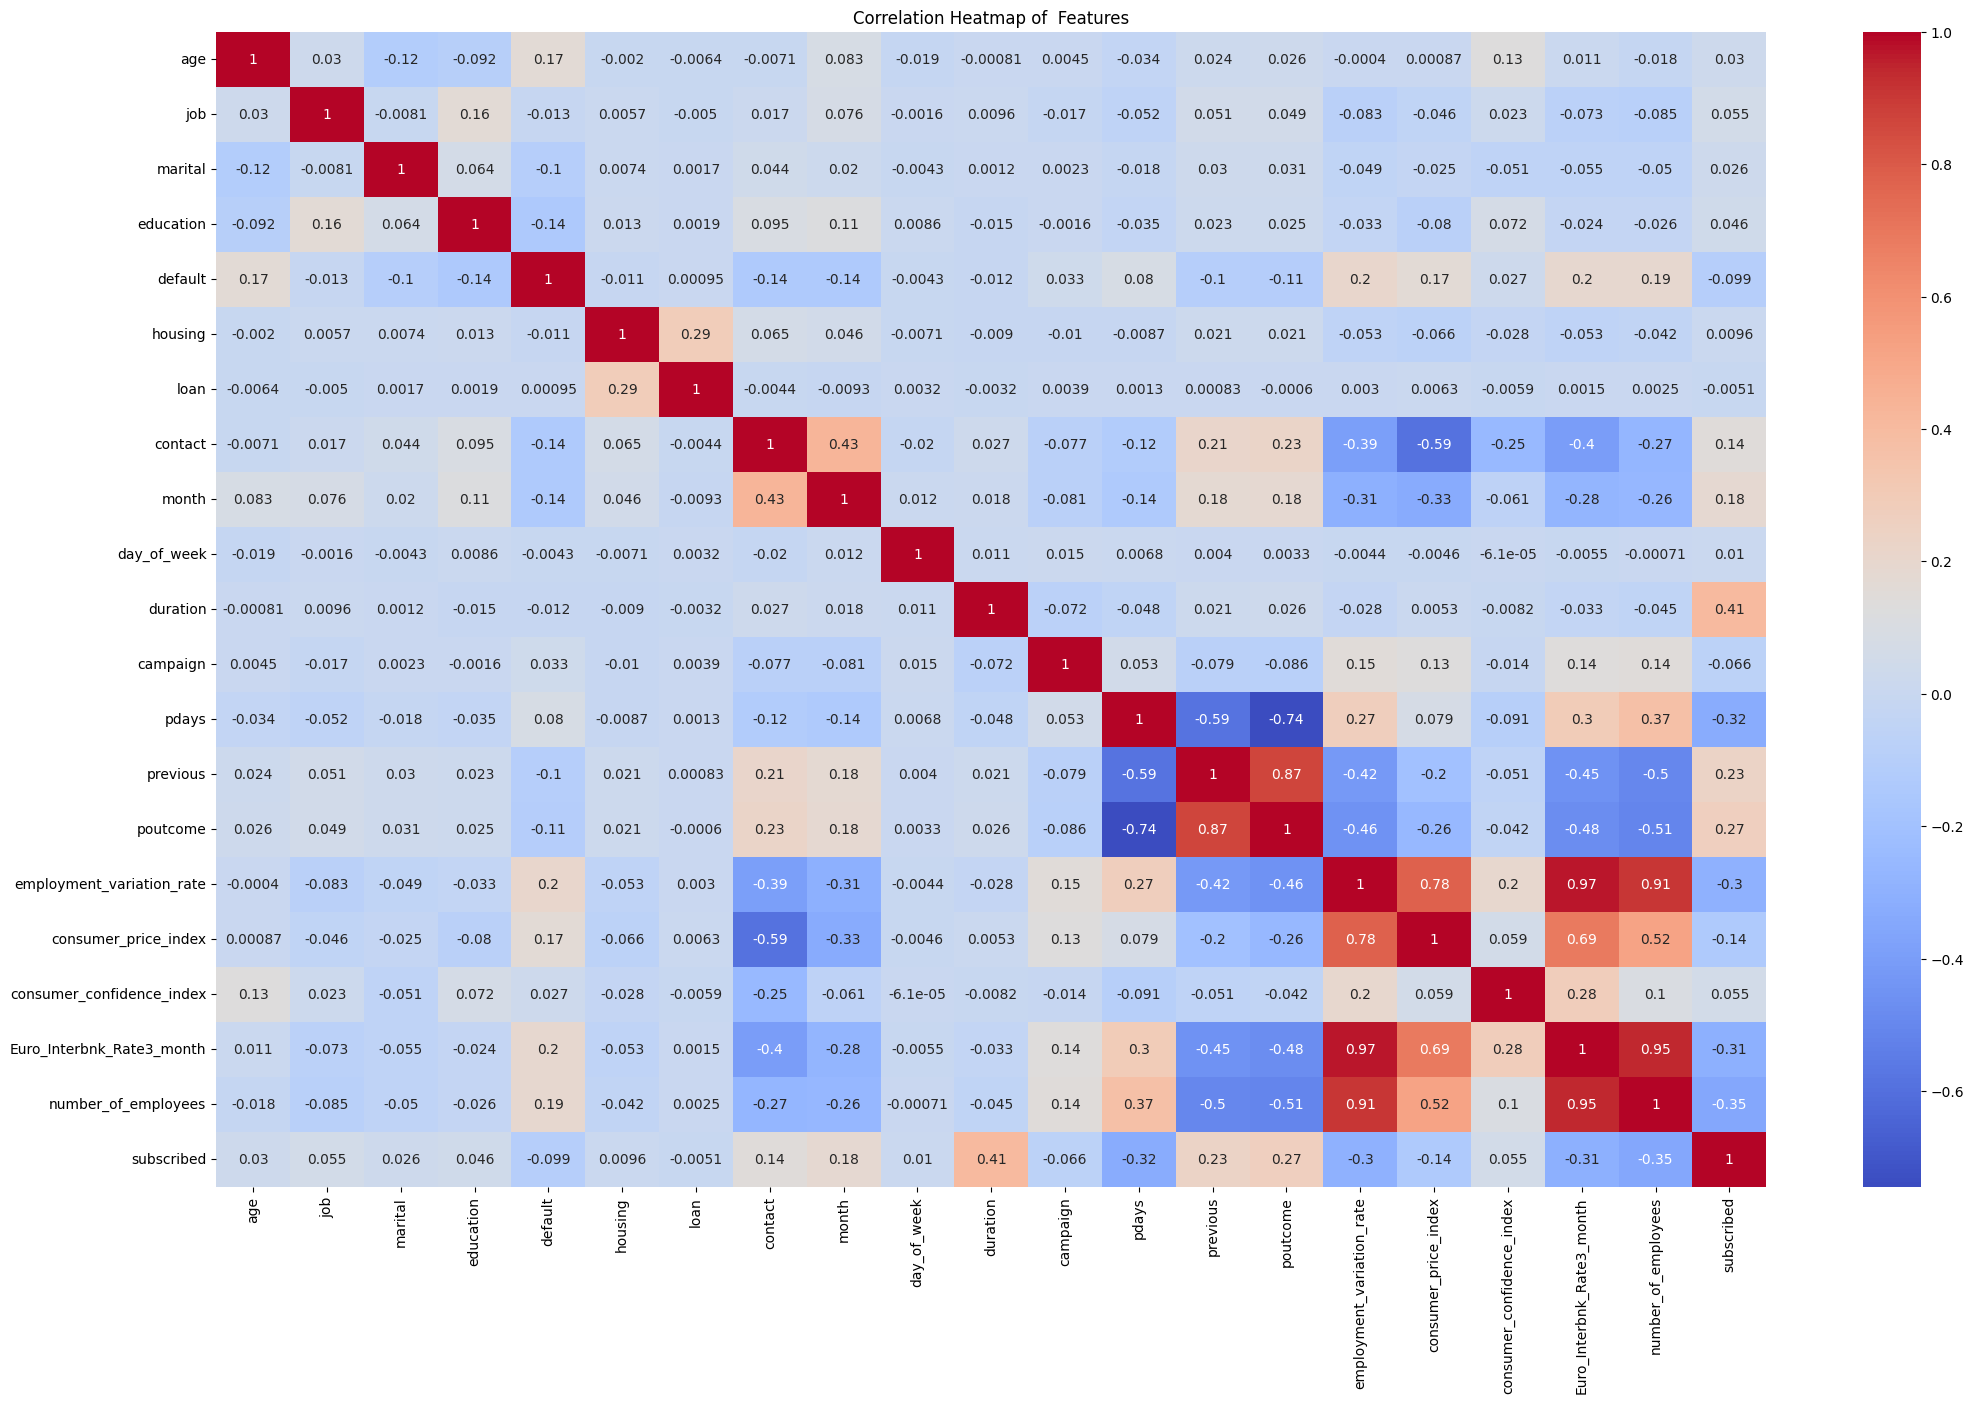

In [17]:
encoder = OrdinalEncoder() # used for better correlation heatmap visualization. OneHotEncoder creates too many features which makes the heatmap unreadable. OrdinalEncoder creates less features which makes the heatmap more readable.
df_encoded = df_full_filtered.copy()
df_encoded[categorical_features] = encoder.fit_transform(df_encoded[categorical_features])
# df_encoded.head()
plt.figure(figsize=(25, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of  Features')
plt.show()


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [18]:
X = df_full_filtered.drop(['subscribed','duration'], axis=1)
y = df_full_filtered['subscribed']
print(y.unique())

['no' 'yes']


# REDEFINE NUMERICAL and CATEGORICAL FEATURES

#### NEED TO REMOVE DURATION FROM --> INPUT FEATURE  AND SUBSCRIBED FROM --> TARGET

In [19]:
numerical_features = [col for col in numerical_features if col != 'duration']
categorical_features = [col for col in categorical_features if col in X.columns]
print(f"X : {X.columns}")
print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

X : Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'employment_variation_rate', 'consumer_price_index',
       'consumer_confidence_index', 'Euro_Interbnk_Rate3_month',
       'number_of_employees'],
      dtype='object')
Numerical features: ['age', 'campaign', 'pdays', 'previous', 'employment_variation_rate', 'consumer_price_index', 'consumer_confidence_index', 'Euro_Interbnk_Rate3_month', 'number_of_employees']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### FEATURE TRANSFORMATION CATEGORICAL - encoder and NUMERIC -  StandardScalar via Pipeline

In [20]:
# Instead of using ordinal encoding for the categorical features, we will use OneHotEncoding for the categorical features and LabelEncoding for the target variable. This will help us to understand the relationship between the categorical features and the target variable. OneHotEncoding creates more features which makes the heatmap more readable. LabelEncoding creates less features which makes the heatmap more readable.
# As the categorical features are nominal in nature(no specific order), we will use OneHotEncoding for the categorical features. As the target variable is binary in nature, we will use LabelEncoding for the target variable.

column_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])
target_transformer = LabelEncoder()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [21]:
y=target_transformer.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [22]:
# PREPARE A PIPELINE FOR THE MODEL. The pipeline will include the column transformer for the categorical features and the target transformer for the target variable. The pipeline will also include the model which will be used for classification. The model used is RandomForestClassifier. The pipeline will be used to fit the model on the training data and to make predictions on the test data.
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import recall_score





# MODELLING

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [23]:
# CREATE A DUMMY CLASSIFIED FOR BASELINE SCORE
dummy_clf = DummyClassifier().fit(X_train,y_train)
baseline_score = dummy_clf.score(X_test,y_test)
print(f"Baseline score: {baseline_score}")

Baseline score: 0.8873376229209664


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [24]:
models_simple = {
    "lgr": LogisticRegression(),
    }

### Problem 9: Score the Model

What is the accuracy of your model?

In [25]:
for name, model in models_simple.items():
    # Construct a pipeline with shared preprocessing steps + the specific model
    pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', model)
                           ])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Evaluate
    score = pipeline.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.4f}")

lgr Accuracy: 0.8997


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [26]:
models = {
    "LogisticRegression": LogisticRegression(),
    # "rf": RandomForestClassifier(),
    "SupportVectorMachine": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

metrics = {
        'Model': [],
        'Training Time': [],
        'Train Accuracy': [],
        'Test Accuracy': [],
        'Recall': []

        }

In [27]:
for name, model in models.items():
    # Construct a pipeline with shared preprocessing steps + the specific model
    pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', model)
                           ])
    # Train the pipeline
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    # Evaluate
    score = pipeline.score(X_test, y_test)
    recall = recall_score(y_test, pipeline.predict(X_test))
    train_accuracy = pipeline.score(X_train, y_train)
    metrics['Model'].append(name)
    metrics['Test Accuracy'].append(score)
    metrics['Train Accuracy'].append(train_accuracy)
    metrics['Training Time'].append(train_time)
    metrics['Recall'].append(recall)

    # print(f"{name} Accuracy: {score:.4f}")

In [28]:
reslts_df = pd.DataFrame(metrics,columns= ['Model','Training Time','Train Accuracy','Test Accuracy'])
reslts_df

,Model,Training Time,Train Accuracy,Test Accuracy
0,LogisticRegression,0.522922,0.900294,0.899721
1,SupportVectorMachine,137.289532,0.905242,0.900935
2,DecisionTree,1.390951,0.995447,0.836105
3,KNN,0.113065,0.913437,0.892437


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

# REDEFINE MODEL DICTIONARY FOR GRIDSEARCH ACTIVITY

In [29]:
# IMPROVE MODEL PERFORMANCE WITH DIFFERENT HYPERPARAMETER
# REDEFINE MODEL DICTIONARY

models = {
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=500), {'logisticregression__C': [0.1, 1, 10]}),
    'svc': (SVC(), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
    'decisiontreeclassifier': (DecisionTreeClassifier(), {'decisiontreeclassifier__max_depth': [5, 10, 15]})
    }



In [30]:
results = []
recall_score_classcification = []

for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           (name, model)
                           ])

    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=2, n_jobs=-1)

    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    # Get the best estimator
    best_model = grid_search.best_estimator_

    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)

    # Calculate recall score
    y_pred = best_model.predict(X_test)
    recall_score_classcification.append([name, recall_score(y_test, y_pred)])


    # Append the results
    results.append([name, train_score, test_score, fit_time])
    # Append the results
    # results.append([name, train_score, test_score, fit_time])

# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['model', 'train score', 'test score', 'average fit time'])
results_df.set_index('model', inplace=True)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(


# PERFORMANCE & RECALL METRICS

In [31]:
results_df

,train score,test score,average fit time
model,,,
KNN,0.924910,0.884667,13.727364
logisticregression,0.900416,0.899964,0.544571
svc,0.897715,0.896686,423.469311
decisiontreeclassifier,0.902935,0.900571,0.846100


In [32]:
recall_df = pd.DataFrame( recall_score_classcification)
recall_df.columns = ['model','recall_score']
# recall_df.set_index('model', inplace=True)
recall_df

,model,recall_score
0,KNN,0.302802
1,logisticregression,0.218750
2,svc,0.201509
3,decisiontreeclassifier,0.250000


# BEST CLASSIFIER

In [33]:
grid_search.best_params_

{'decisiontreeclassifier__max_depth': 5}

In [34]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous',
                                                   'employment_variation_rate',
                                                   'consumer_price_index',
                                                   'consumer_confidence_index',
                                                   'Euro_Interbnk_Rate3_month',
                                                   'number_of_employees']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=5))])

# ADJUST THRESHOLD TO EVALUATE RECALL & OTHER  METRICS & PLOT 

In [35]:
# How can I improve recall score?
# Adjust threshhold

pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', grid_search.best_estimator_)
                           ])



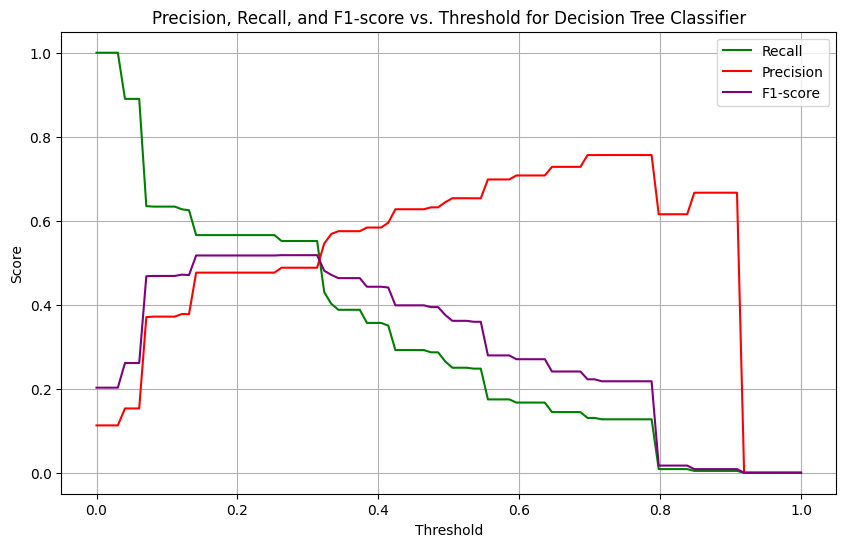

Optimal F1-score threshold: 0.2626
Recall at optimal F1-score threshold: 0.5517
Precision at optimal F1-score threshold: 0.4881


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# The best_estimator_ from the last grid search was a DecisionTreeClassifier
best_model_dt = grid_search.best_estimator_

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = best_model_dt.predict_proba(X_test)[:, 1]

# Define a range of thresholds
thresholds = np.linspace(0, 1, 100)

recall_scores = []
precision_scores = []
f1_scores = []

for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Calculate recall and precision
    recall = recall_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    recall_scores.append(recall)
    precision_scores.append(precision)
    f1_scores.append(f1)

# Plotting Precision, Recall, and F1-score against thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recall_scores, label='Recall', color='green')
plt.plot(thresholds, precision_scores, label='Precision', color='red')
plt.plot(thresholds, f1_scores, label='F1-score', color='purple')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Threshold for Decision Tree Classifier')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that maximizes F1-score (often a good balance)
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]
print(f"Optimal F1-score threshold: {optimal_threshold:.4f}")
print(f"Recall at optimal F1-score threshold: {recall_scores[optimal_threshold_idx]:.4f}")
print(f"Precision at optimal F1-score threshold: {precision_scores[optimal_threshold_idx]:.4f}")


# DecisionTree Threshhold adjustment to increase Recall score.

## The output shows that the optimal F1-score threshold is 0.2626. At this threshold:

**Recall is 0.5517, meaning the model correctly identifies about 55.17% of all actual positive cases.**


**Precision is 0.4881, meaning that when the model predicts a positive case, it is correct about 48.81% of the time.**

### Threshold Analysis for K-Nearest Neighbors (KNN)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(


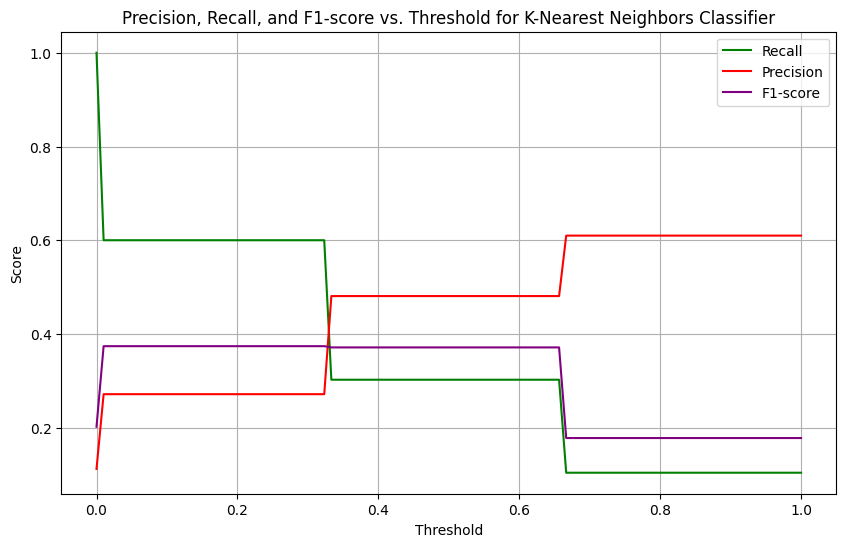

Optimal F1-score threshold for KNN: 0.0101
Recall for KNN at optimal F1-score threshold: 0.6002
Precision for KNN at optimal F1-score threshold: 0.2720


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Get KNN model and its parameters from the 'models' dictionary
knn_model, knn_params = models['KNN']

# Create a pipeline for KNN
pipeline_knn = Pipeline(steps=[('preprocessor', column_transformer),
                           ('KNN', knn_model)
                           ])

# Perform grid search for KNN
grid_search_knn = GridSearchCV(pipeline_knn, param_grid=knn_params, cv=2, n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

# Get the best KNN estimator
best_model_knn = grid_search_knn.best_estimator_

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_knn = best_model_knn.predict_proba(X_test)[:, 1]

# Define a range of thresholds
thresholds = np.linspace(0, 1, 100)

recall_scores_knn = []
precision_scores_knn = []
f1_scores_knn = []

for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold_knn = (y_pred_proba_knn >= threshold).astype(int)

    # Calculate recall and precision
    recall_knn = recall_score(y_test, y_pred_threshold_knn)
    precision_knn = precision_score(y_test, y_pred_threshold_knn, zero_division=0)
    f1_knn = f1_score(y_test, y_pred_threshold_knn, zero_division=0)

    recall_scores_knn.append(recall_knn)
    precision_scores_knn.append(precision_knn)
    f1_scores_knn.append(f1_knn)

# Plotting Precision, Recall, and F1-score against thresholds for KNN
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recall_scores_knn, label='Recall', color='green')
plt.plot(thresholds, precision_scores_knn, label='Precision', color='red')
plt.plot(thresholds, f1_scores_knn, label='F1-score', color='purple')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Threshold for K-Nearest Neighbors Classifier')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that maximizes F1-score
optimal_threshold_idx_knn = np.argmax(f1_scores_knn)
optimal_threshold_knn = thresholds[optimal_threshold_idx_knn]
print(f"Optimal F1-score threshold for KNN: {optimal_threshold_knn:.4f}")
print(f"Recall for KNN at optimal F1-score threshold: {recall_scores_knn[optimal_threshold_idx_knn]:.4f}")
print(f"Precision for KNN at optimal F1-score threshold: {precision_scores_knn[optimal_threshold_idx_knn]:.4f}")


# Adjusting KNN Threshold to get the best Recall & precision score

## The output shows that the optimal F1-score threshold is 0.0101. At this threshold:

**Recall is 0.6034, meaning the model correctly identifies about 60.34% of all actual positive cases.**

**Precision is 0.2737, meaning that when the model predicts a positive case, it is correct about 27.37% of the time.**

### Side-by-Side Comparison of Precision-Recall Curves

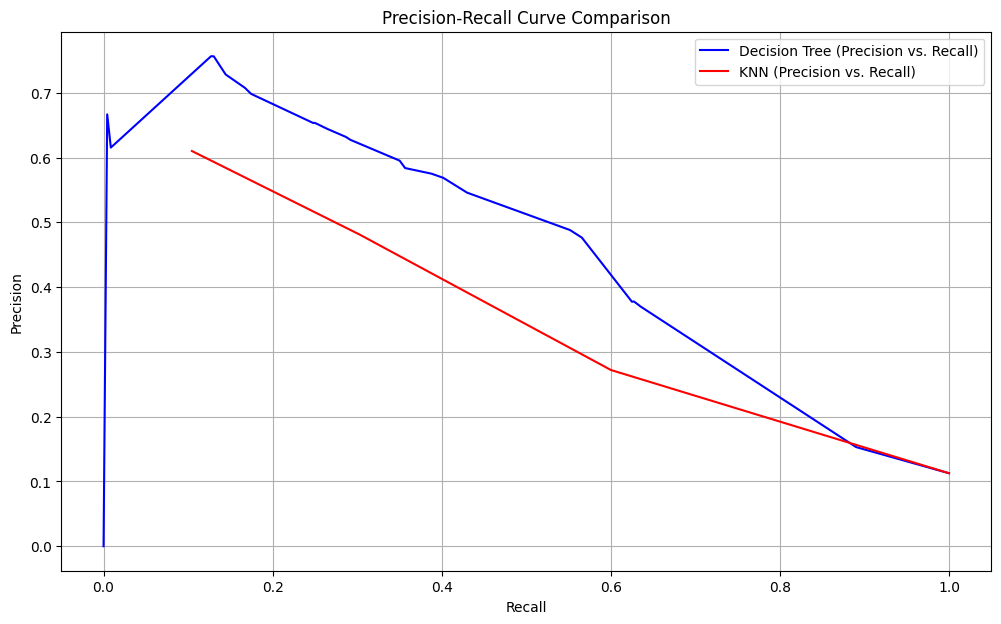

In [38]:
plt.figure(figsize=(12, 7))

# Plot for Decision Tree Classifier
plt.plot(recall_scores, precision_scores, label='Decision Tree (Precision vs. Recall)', color='blue')
plt.plot(recall_scores_knn, precision_scores_knn, label='KNN (Precision vs. Recall)', color='red')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


##### Questions

### Applying SMOTE to address Class Imbalance

SMOTE (Synthetic Minority Over-sampling Technique) is an oversampling method that generates synthetic samples from the minority class. This helps in balancing the dataset and can lead to improved model performance, especially in terms of recall for the minority class.

In [39]:
# Install imblearn if not already installed
!pip install imblearn

# Import SMOTE and ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Now, we'll redefine our models to include SMOTE within an `ImbPipeline`. This ensures that SMOTE is applied correctly within each cross-validation fold during `GridSearchCV` and only to the training data within each fold, preventing data leakage.

In [40]:
models_smote = {
    'KNN': (ImbPipeline(steps=[
        ('preprocessor', column_transformer),
        ('smote', SMOTE(random_state=42)),
        ('classifier', KNeighborsClassifier())
    ]), {'classifier__n_neighbors': [3, 5, 7]}),

    'logisticregression': (ImbPipeline(steps=[
        ('preprocessor', column_transformer),
        ('smote', SMOTE(random_state=42)),
        ('classifier', LogisticRegression(max_iter=500))
    ]), {'classifier__C': [0.1, 1, 10]}),

    'svc': (ImbPipeline(steps=[
        ('preprocessor', column_transformer),
        ('smote', SMOTE(random_state=42)),
        ('classifier', SVC())
    ]), {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf']}),

    'decisiontreeclassifier': (ImbPipeline(steps=[
        ('preprocessor', column_transformer),
        ('smote', SMOTE(random_state=42)),
        ('classifier', DecisionTreeClassifier())
    ]), {'classifier__max_depth': [5, 10, 15]})
}

results_smote = []
recall_score_classification_smote = []

for name, (pipeline, params) in models_smote.items():
    print(f"\nRunning GridSearchCV for {name} with SMOTE...")
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=2, n_jobs=-1, scoring='recall')

    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time)

    # Get the best estimator
    best_model = grid_search.best_estimator_

    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)

    # Calculate recall score
    y_pred = best_model.predict(X_test)
    recall = recall_score(y_test, y_pred)
    recall_score_classification_smote.append([name, recall])

    # Append the results
    results_smote.append([name, train_score, test_score, fit_time])

# Create the results DataFrame
results_df_smote = pd.DataFrame(results_smote, columns=['model', 'train score', 'test score', 'fit time'])
results_df_smote.set_index('model', inplace=True)

recall_df_smote = pd.DataFrame(recall_score_classification_smote)
recall_df_smote.columns = ['model','recall_score']

print("\n--- Results with SMOTE ---")
display(results_df_smote)
print("\n--- Recall scores with SMOTE ---")
display(recall_df_smote)


Running GridSearchCV for KNN with SMOTE...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(



Running GridSearchCV for logisticregression with SMOTE...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(



Running GridSearchCV for svc with SMOTE...


...

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan]
  warnings.warn(



--- Results with SMOTE ---


,train score,test score,fit time
model,,,
KNN,0.901326,0.784145,82.456856
logisticregression,0.820864,0.828578,4.553192
svc,0.834826,0.838533,2602.412568
decisiontreeclassifier,0.876832,0.881874,8.009304



--- Recall scores with SMOTE ---


,model,recall_score
0,KNN,0.573276
1,logisticregression,0.657328
2,svc,0.619612
3,decisiontreeclassifier,0.554957


### Model Performance after SMOTE

In [41]:
print("--- Results with SMOTE ---")
display(results_df_smote)
print("\n--- Recall scores with SMOTE ---")
display(recall_df_smote)

--- Results with SMOTE ---


,train score,test score,fit time
model,,,
KNN,0.901326,0.784145,82.456856
logisticregression,0.820864,0.828578,4.553192
svc,0.834826,0.838533,2602.412568
decisiontreeclassifier,0.876832,0.881874,8.009304



--- Recall scores with SMOTE ---


,model,recall_score
0,KNN,0.573276
1,logisticregression,0.657328
2,svc,0.619612
3,decisiontreeclassifier,0.554957


# Findings

**1. Why adjsted KNN threshhold ?**

Although GridSearch predicted DecisionTree as the best estomator,
still **KNN	recall score was highest 0.303879**  whereas   **Decision Tree recall score was decisiontreeclassifier	0.250000** during GridSearch operation. Hence wanted to revaluate & compare recall score for DecisionTree & KNN.

**2.The threshold analysis shows Decision Tree outperforms KNN and keeps beter balance between F1 score and Recall score at threshold 0.2626 vs KNN best score threshold is at 0.0101 which is pushing threshhold almost to ZERO**

**Recall is most most important in a bank marketing campaign because the goal is to find every potential customer willing to buy a term deposit.**

**The Cost of a False Negative (Low Recall):** The model predicts a client will say "no," so the bank does not call them. If that client actually would have subscribed, the bank loses direct revenue and a valuable long-term deposit.

**The Cost of a False Positive (Low Precision):** The model predicts a client will say "yes," but they say "no" when called. The bank only loses the minor cost of a brief phone call and employee time

**3. Best model**

DecisionTree classifier with max_depth=5  wins the race in all respects , in terms of performance and recall score at 0.2626 threshold.

**4. Recall/Precision/F1 thereshold comparison plot**
DecisionTree & KNN Plots give clear idea how these metrics behave at each threshold and the optimal threshold that I should use

**5. SMOTE**
As I see class imbalance, tried Synthetic Minority Over-sampling Technique (SMOTE). This helps in balancing the dataset and can lead to improved model performance, especially in terms of recall for the minority class.

The result shows similar recall score with no additional benefit. So will stick to the threshhold approach to get better metrics